In the name of God

# Q2: Clinical Event Time Series Prediction

## 2.1. Introduction:

In the following notebook we will be implementing various methods for predicting clinical event time series such as LSTM, GRU, ...

We will be using the work done on this paper (https://people.cs.pitt.edu/~milos/research/2019/Lee_Hauskrecht_AIME_2019.pdf) as our baseline and use the MIMIC-III dataset (https://www.kaggle.com/datasets/salikhussaini49/prediction-of-sepsis) to train and evaluate our models.

## 2.2. Methodology

### 2.2.1. How are time series prediction problems formatted?

Predicting time series often involves using the past information about a sequence to make a prediction about the next state (or multiple states) of a sequence / patter.

Putting it in a mathematical format, given the sequence y1, y2, ... yt the goal is to use information about this given sequence (like the patterns and dependencies) to guess yt+1.

In the context of machine learning these y values can be either discreet vectors identifying different classes (classification) or real valued vector (regression), and we usually develop an algorithm to do this predictions for us, below are a few examples that were mentioned in the paper:

* __Markov Models__: 
    This method models the probability of transitioning from the current state to the next state using a transition matrix, in the paper $ p(y_{t+1} | y_t)$ defines the probability of the next state given the current state.

    This method mainly focuses on the most recent events

* __Hidden Markov Models (HMM)__: 
    To remedy the issue of only focusing on recent events, this model implements a hidden state to capture the previous events, in the paper $ p(z_{t+1} | z_t) $ is the transition probability between hidden states and emission probabilities $ p(y_t | z_t) $.

* __Recurrent Neural Networks (RNN)__:
    Similar to HMM, these models retain a hidden state to act as a memory of past events. These models are often trained using various learning methods such as BPTT and they often have a short memory (due to gradient vanishing).

    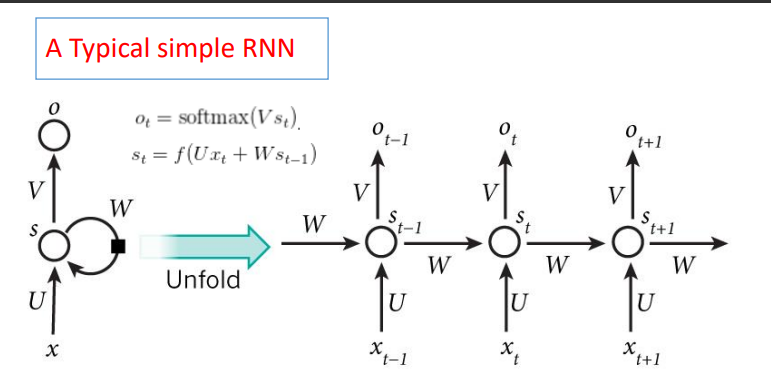

* __Long Short-Term Memory (LSTM)__:
    These models have been developed to enhance the RNNs by having a cell state and a hidden state and preforming operations such as forgetting using various gates to enable the model to have a much longer memory and attempt to solve the issue of gradient vanishing.

    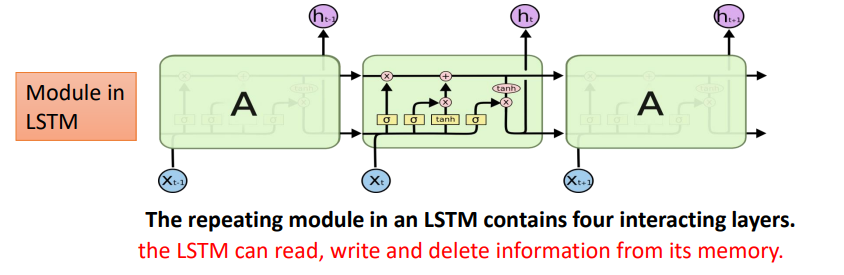

* __Gated Recurrent Unit (GRU)__: 
    GRUs are a simplified version of LSTMs that change the update and reset gates to reduce the complexity of the model and enable better training and performance.

    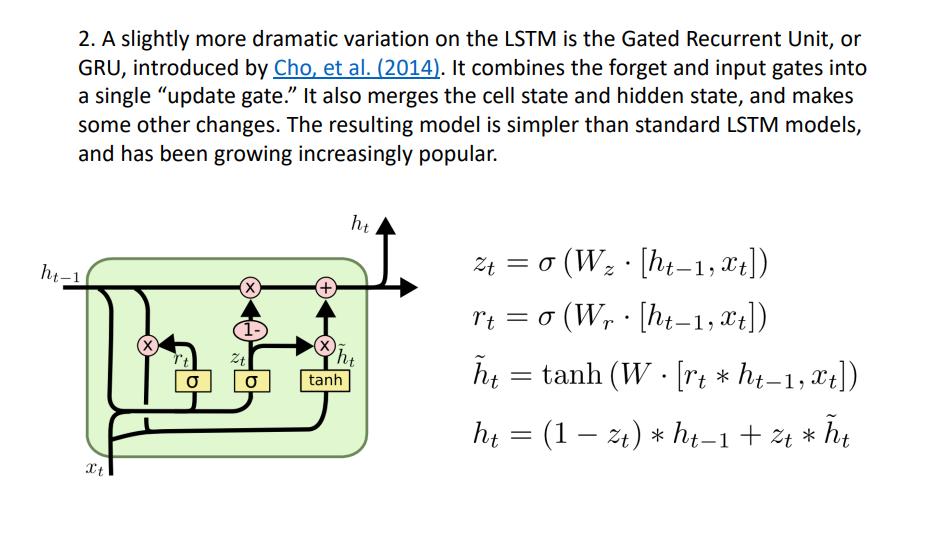


### 2.2.2. State-Space Markov Event prediction

#### 2.2.2.1. How does State-Space Markov Event prediction work?

These models which are based on the Markov processes are designed to predict the future states form the current state (a state in our case could be the medication given to the patient). These methods use a transition matrix which encodes the probability of moving form one state to the other and leverages the Markovian property that the next event is only dependant on the current state, hence they have a rather short memory and aren't very good at detecting past events that might influence the next action.

#### 2.2.2.2. Designing a Dense Neural Network for Markov Event prediction

We can use a dense neural network to encode and understand our transition matrix, removing the need to manually calculate the probabilities, before we design such a network lets first answer a few questions:

* __Can we use layers like Normalization?__
    The paper did not mention using these layers but I don't see and reason why we wouldn't be able to implement them, in the classic markov based approaches, the transition matrix needs to represent the probabilities, but in our neural network we don't really care about the state in the hidden layers of the network and the output values (assuming we'll use a sigmoid function at the output layer) will be converted to probabilities so as long as it improves the performance of the model it really shouldn't matter if we used a normalization layer in the hidden layers of our network.

* __Which activation functions to use?__
    If we want to commit exactly to the Markov models, there is not much non linearity in it and thus we shouldn't use not linear activation functions. But since most natural phenomena have some sort of non linearity, I believe it would be a waste to not use this capability of neural network, thus I employed Relu functions.

    Another important note to consider is, there's a good chance that the network will not converge properly if we don't use any activation functions.

For the model, we used the following structure:
* __Input__: N-dimensional vector representing the current state. (the value of N will be assigned based on the input data in the next section)
* __Hidden Layer__: 128 units with ReLU as the activation function. 
* __Output__: N-dimensional vector with sigmoid activation $ f(x) = \frac{1}{1 + e^{-x}} $, yielding probabilities for the next state’s events.

Number of hidden neuron (128), loss function (binary_crossentropy) and the learning rate (0.005) were chosen based on the paper

__At this stage I thought I should be replicating the models discussed in the paper and thus the output is a vector distinguishing the classes, during the next section I realized the goal is to design a network to predict HR which is a regression task, the models have been adjusted for this in the later parts__

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models

N = 100
learning_rate = 0.005

model = models.Sequential([
    layers.Input(shape=(N,)),
    layers.Dense(128, activation='relu', name='Hidden Layer'),
    layers.Dense(N, activation='sigmoid', name='Output')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

batch_size = 32

2025-05-31 22:13:09.115462: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-05-31 22:13:09.124558: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748716989.134491  113558 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748716989.137652  113558 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1748716989.145699  113558 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Hidden Layer (Dense)            │ (None, 128)            │        12,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 100)            │        12,900 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,828 (100.89 KB)

 Trainable params: 25,828 (100.89 KB)

 Non-trainable params: 0 (0.00 B)

### 2.2.3. How do event-based LSTM prediction methods work?

LSTMs are designed to have a longer short term memory (compared to previous methods such as RNNs) and are used to work with sequential data, event-based predictions are one such example which often come with a time step to indicated when each even has occurred. They used a hidden state (as well as a cell state vector) to be able to encode previous data efficiently while retaining valuable information, the do this by using gates that are as follows:
* __Forget Gate__: using a the hidden state of the previous cell concatenated with the input information and preforming a matrix multiplication and passing it through a softmax layer, the module decided what information to forget.

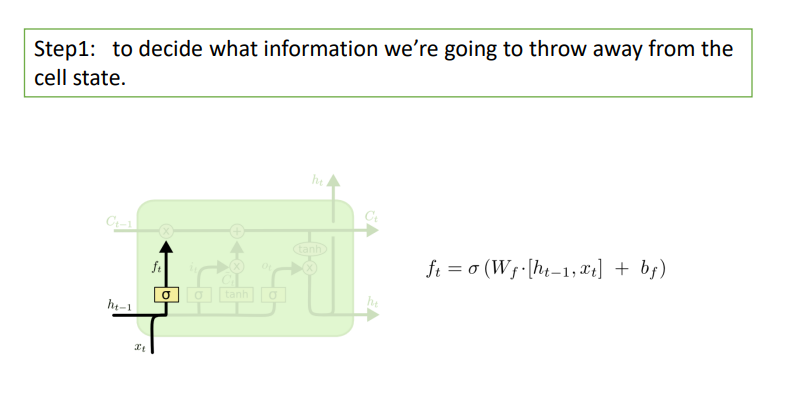

* __Input Gate__: again using the previous hidden state and the input, it decides what information to add to the cell state by passing it through a tanh activation function and multiplying it by the output of the sigmoid (to calculate the values and choosing how much effect each have respectively)

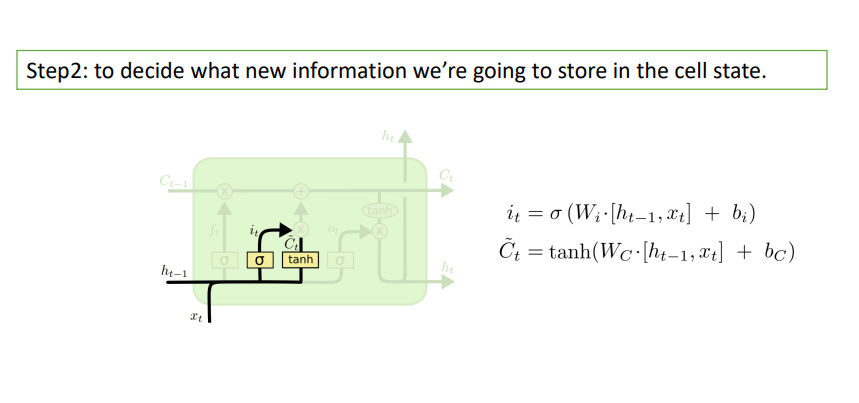

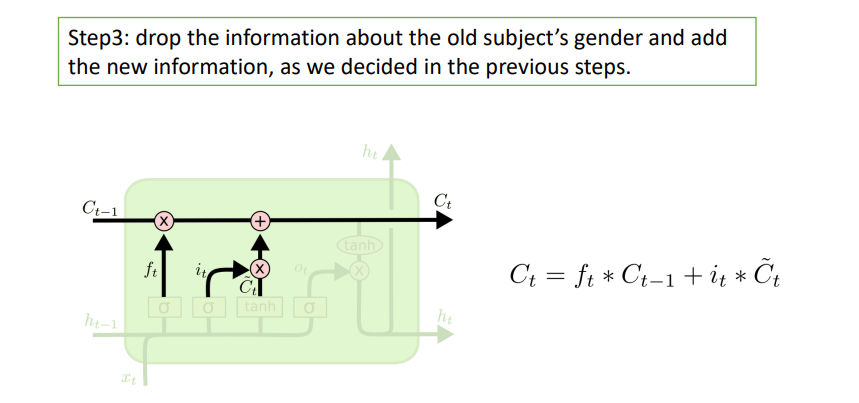

* __Output Gates__: After that, based on the information of the cell state (by passing it through an activation function like tanh) and using the hidden state of the previous iteration concatenated with the input of the model, the hidden state of the current step is calculated. This hidden state is then used to produce the output if necessary (by passing through a sigmoid function for classification or through a dense network, etc.)

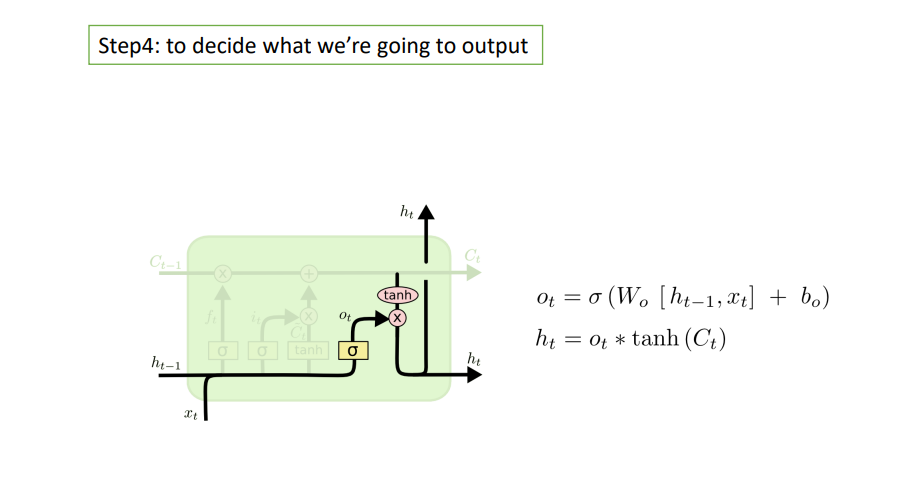

In the image below we can see all the equations for the LSTM

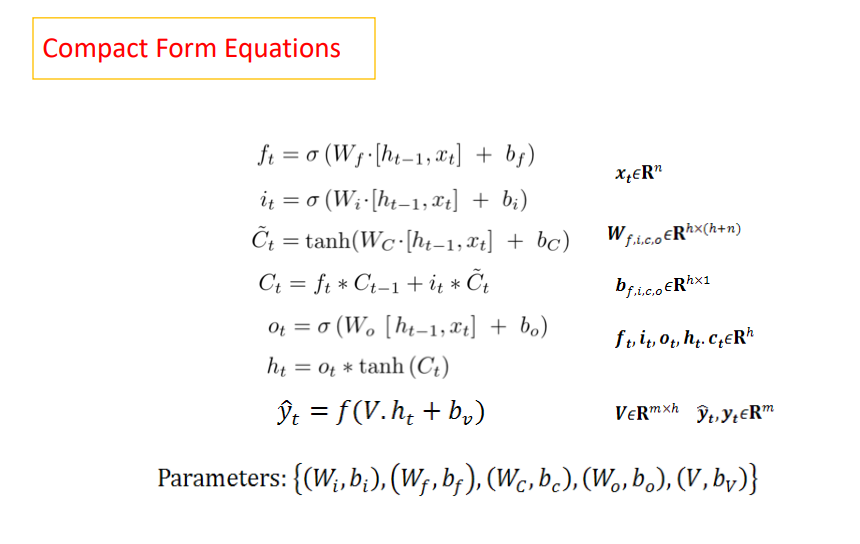

For the LSTM we define the loss function based on our application (for example in the paper, a cross entropy loss was utilized as it was a classification problem) and the model is trained using back propagation through time (BPTT), which is due to the fact that the weights of the LSTM are fixed for all the inputs (each step).

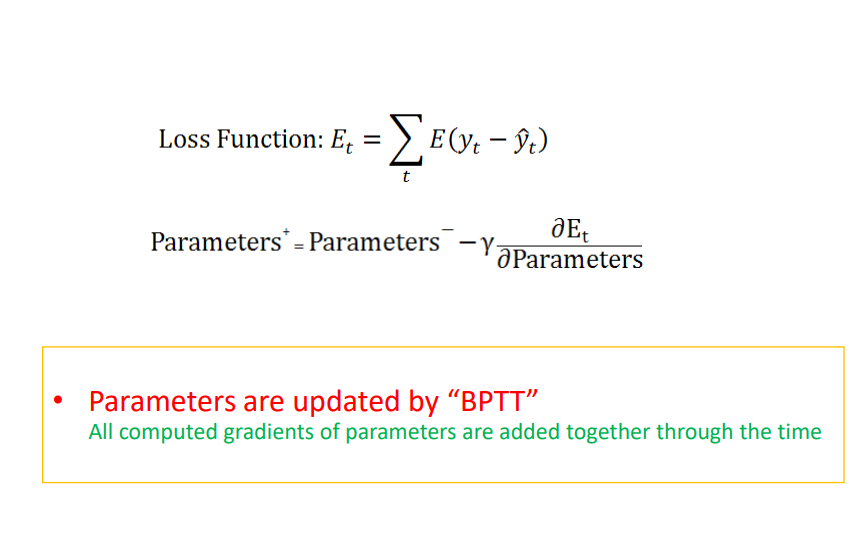

Below we can see other methods used for training LSTMs:

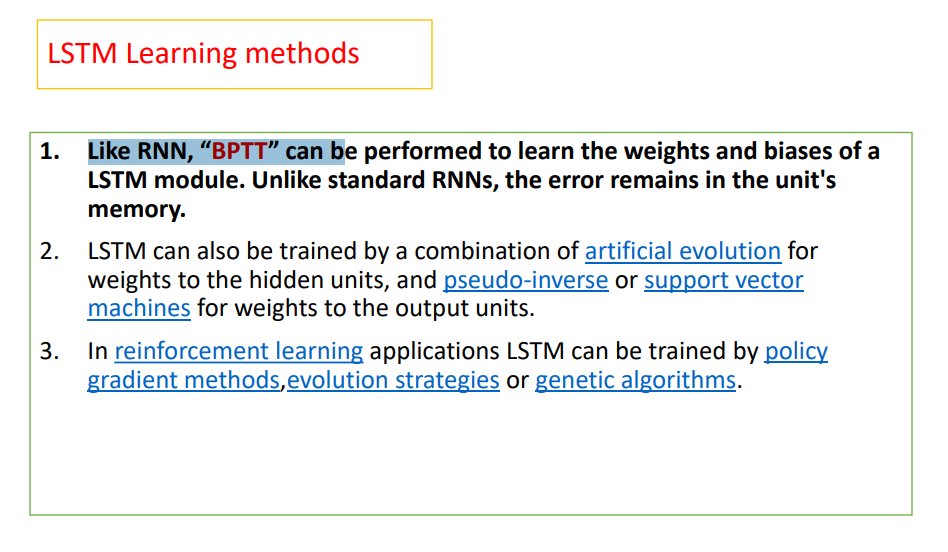

To clarify the training process further, we will go through a forward pass iteration step by sep:

* __Initial State__: Initially the cell contains information from time 0 to t - 1

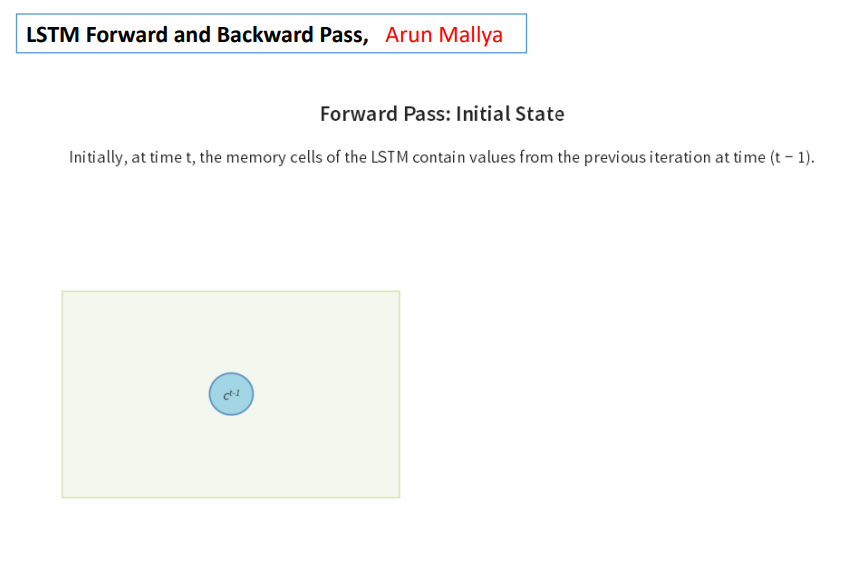

* __Input and Gate computation__: If we look at the equations of the LSTM, we can see that many of the calculations can be done simultaneously. To achieve better performance we will combine these operations into matrix calculations as explained in the image below

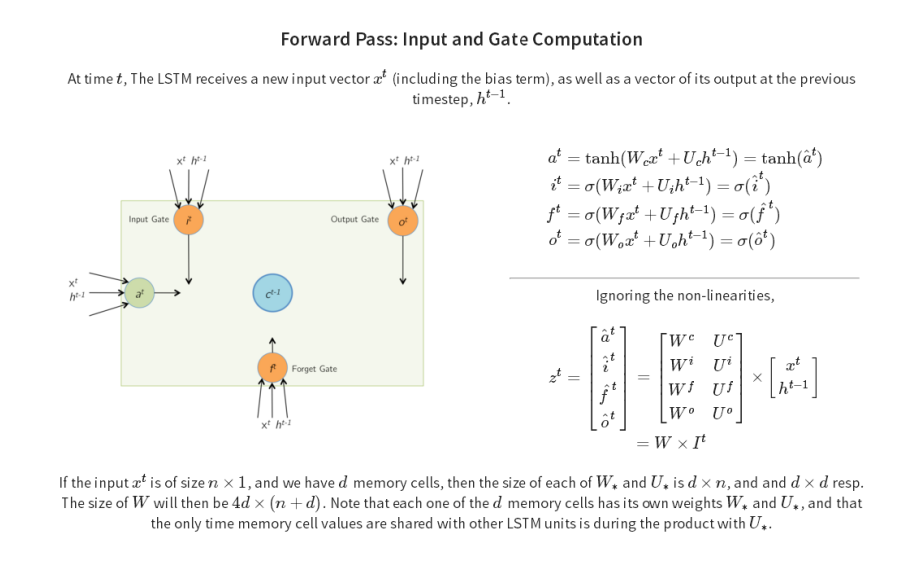

* __Memory cell update__: Then we will use the values calculated in the previous section to update the memory cell (cell state) based on the previously explained equations

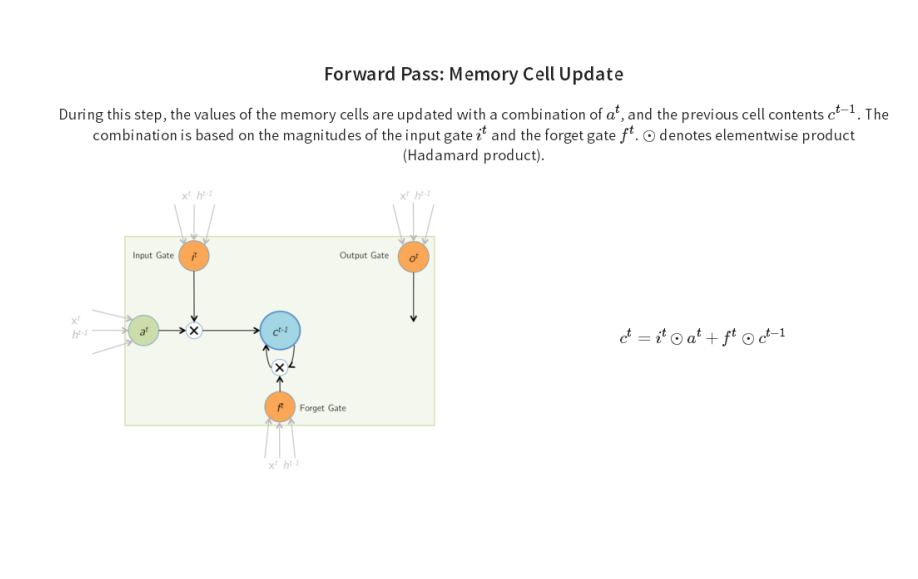

* __Output__: At last, we will calculate the output

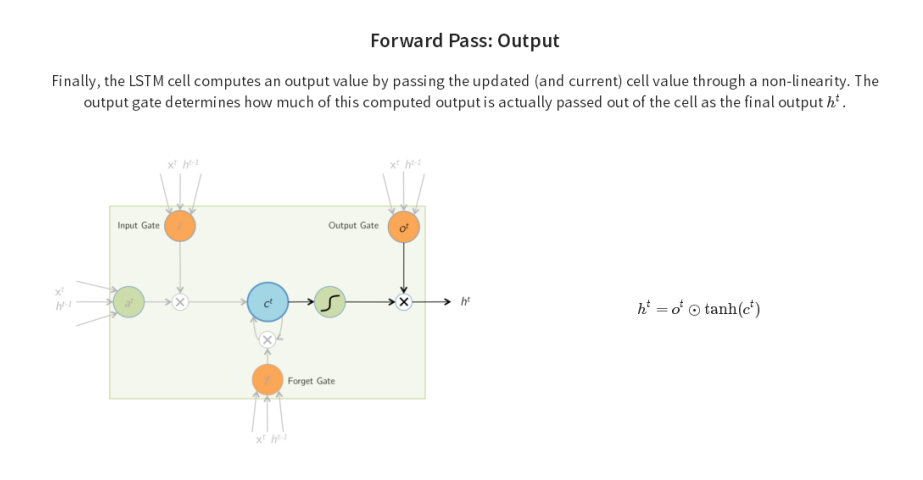

Below you can see the summary of this process.

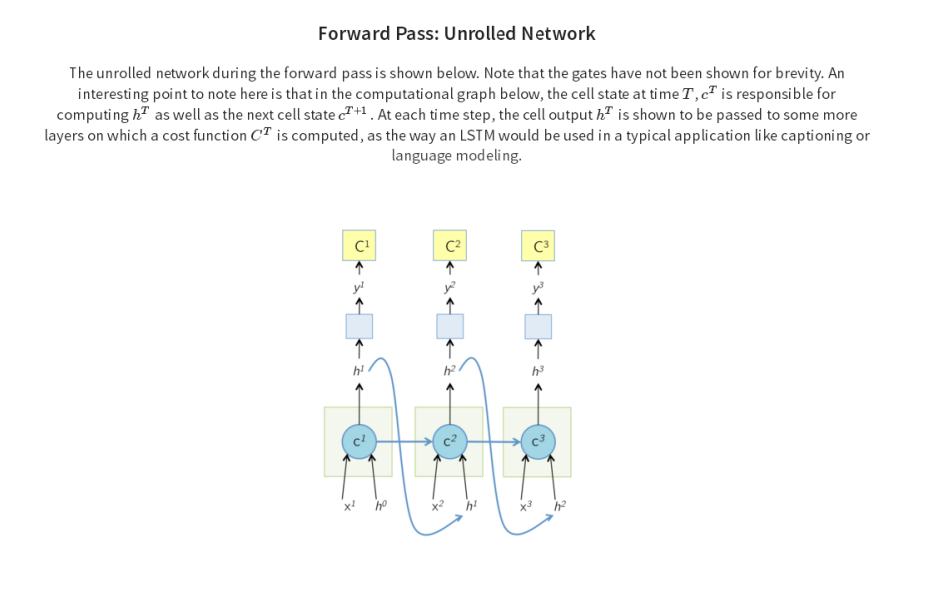

No we will implement the network (the input's been adjusted based on the data preprocessing), since we will be replacing the back bone (LSTM) of the paper with 3 other different models in the next section, we will write the code in a way that facilitates this

The structure is quite similar to the LSTM network with two key differences:

1. We embed the data before giving it to the LSTM since it's a sparse multi-hot vector, we do this to both reduce the inputs size and improve the LSTM performance (similar to word embedding in NLP)

2. We add the output of the recent dense model (similar to the previously discussed network) to the LSTM's output before passing it to the classifier

In [2]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense, LSTM, TimeDistributed, Add, Activation
from tensorflow.keras.models import Model

T = 24
N = 100  
D = 128  
H = 256  
dropout_rate = 0.5 

input_seq = Input(shape=(T, N))

embedded = TimeDistributed(Dense(D, activation=None))(input_seq)

rnn_out = LSTM(H, return_sequences=True, dropout=dropout_rate)(embedded)

rnn_dense = TimeDistributed(Dense(N, activation=None))(rnn_out)

recent_dense = TimeDistributed(Dense(N, activation=None))(input_seq)

combined = Add()([rnn_dense, recent_dense])

prediction = Activation('sigmoid')(combined)

lstm_model = Model(inputs=input_seq, outputs=prediction)

lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

lstm_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 24, 100)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 24, 128)   │     12,928 │ input_layer_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 24, 256)   │    394,240 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 24, 100)   │     25,700 │ lstm[0][0]        │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_2  │ (None, 24, 100)   │     10,100 │ input_layer_1[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 24, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 24, 100)   │          0 │ add[0][0]         │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 442,968 (1.69 MB)

 Trainable params: 442,968 (1.69 MB)

 Non-trainable params: 0 (0.00 B)

### 2.2.4. Coding different Models:

In this section we will be giving a brief explanation of each model and then implementing them.

#### 2.2.4.1. Bi-Directional LSTM

A Bi-Directional LSTM is an enhanced version of LSTM that is designed to process information (sequential data) in two direction (a front direction like the normal LSTM and a backward direction). This dual processing allows the network to get the context of the data both from the future and the past, making it useful for applications where the entire sequence is available!

The working operation of Bi-Directional LSTM is quite simple, it employs two LSTMs:
* __Forward LSTM__: A LSTM network that processes the sequence in the normal way (getting the inputs x1, x2, ... and producing the hidden states h1, h2, ...)

* __Backward LSTM__: A LSTM tha process the same sequence but in backwards meaning it gets the information xT, xT - 1, ... and produces the hidden states h'T, h'T - 1, ...

These two hidden states are then combined (usually concatenated) to a single hidden state, which is then used to produce the output (for example by passing through a MLP). This enables the model to have the information from both the past and the future!

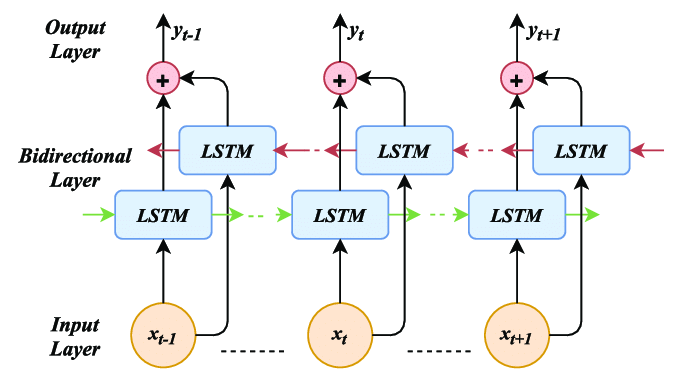

While the Bi-Directional LSTM is usually better at extracting features and show better performance in complex tasks, it requires (at least) twice the computation power and the fact that it uses the data from the future, makes it unsuitable for real-time applications. We will now change the code for the LSTM backbone to use the Bi-Directional LSTM.

In [3]:
from tensorflow.keras.layers import GRU, Bidirectional

input_seq = Input(shape=(T, N))

embedded = TimeDistributed(Dense(D, activation=None))(input_seq)

rnn_out = Bidirectional(LSTM(H, return_sequences=True, dropout=dropout_rate))(embedded)

rnn_dense = TimeDistributed(Dense(N, activation=None))(rnn_out)

recent_dense = TimeDistributed(Dense(N, activation=None))(input_seq)

combined = Add()([rnn_dense, recent_dense])

prediction = Activation('sigmoid')(combined)

bi_LSTM_model = Model(inputs=input_seq, outputs=prediction, name='bi_LSTM_model')

bi_LSTM_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bi_LSTM_model.summary()

Model: "bi_LSTM_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 100)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_3  │ (None, 24, 128)   │     12,928 │ input_layer_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 24, 512)   │    788,480 │ time_distributed… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_4  │ (None, 24, 100)   │     51,300 │ bidirectional[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_5  │ (None, 24, 100)   │     10,100 │ input_layer_2[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 24, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 24, 100)   │          0 │ add_1[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 862,808 (3.29 MB)

 Trainable params: 862,808 (3.29 MB)

 Non-trainable params: 0 (0.00 B)

#### 2.2.4.2. Gated Recurrent Unit (GRU)

Gated Recurrent Unit (GRU) is a simplified version of LSTM, its most notable difference with LSTM are the usage of fewer gates and removal of one of the state vectors, below we can see a simple illustration of it.

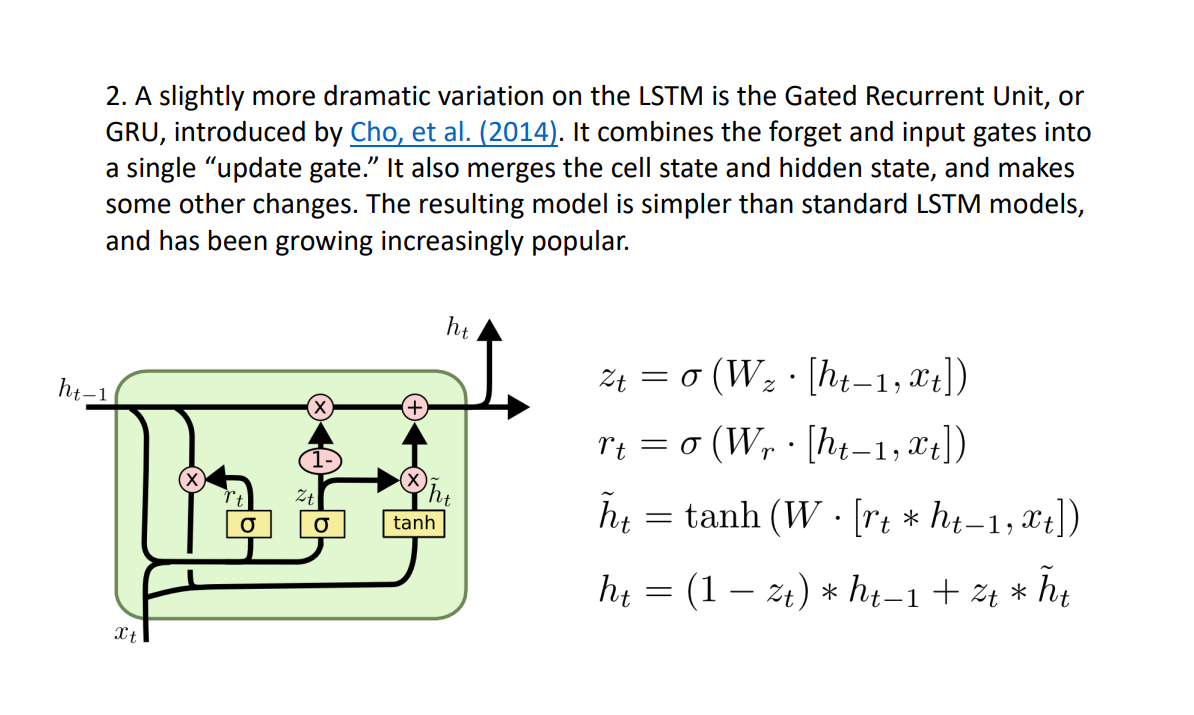

Now we will change the code to implement GRU as the backbone.

In [4]:
input_seq = Input(shape=(T, N))

embedded = TimeDistributed(Dense(D, activation=None))(input_seq)

rnn_out = GRU(H, return_sequences=True, dropout=dropout_rate)(embedded)

rnn_dense = TimeDistributed(Dense(N, activation=None))(rnn_out)

recent_dense = TimeDistributed(Dense(N, activation=None))(input_seq)

combined = Add()([rnn_dense, recent_dense])

prediction = Activation('sigmoid')(combined)

gru_model = Model(inputs=input_seq, outputs=prediction, name='gru_model')

gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

gru_model.summary()

Model: "gru_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 24, 100)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_6  │ (None, 24, 128)   │     12,928 │ input_layer_3[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 24, 256)   │    296,448 │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_7  │ (None, 24, 100)   │     25,700 │ gru[0][0]         │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_8  │ (None, 24, 100)   │     10,100 │ input_layer_3[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 24, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 24, 100)   │          0 │ add_2[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 345,176 (1.32 MB)

 Trainable params: 345,176 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

#### 2.2.4.3. Bi-Directional Gated Recurrent Unit (GRU)

Similar to Bi-Directional LSTM we can use the GRU in a Bi-Directional manner with the same advantages and disadvantages.

In [5]:
input_seq = Input(shape=(T, N))

embedded = TimeDistributed(Dense(D, activation=None))(input_seq)

rnn_out = Bidirectional(GRU(H, return_sequences=True, dropout=dropout_rate))(embedded)

rnn_dense = TimeDistributed(Dense(N, activation=None))(rnn_out)

recent_dense = TimeDistributed(Dense(N, activation=None))(input_seq)

combined = Add()([rnn_dense, recent_dense])

prediction = Activation('sigmoid')(combined)

bi_gru_model = Model(inputs=input_seq, outputs=prediction, name='bi_gru_model')

bi_gru_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

bi_gru_model.summary()

Model: "bi_gru_model"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 24, 100)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_9  │ (None, 24, 128)   │     12,928 │ input_layer_4[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 24, 512)   │    592,896 │ time_distributed… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_10 │ (None, 24, 100)   │     51,300 │ bidirectional_1[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_11 │ (None, 24, 100)   │     10,100 │ input_layer_4[0]… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 24, 100)   │          0 │ time_distributed… │
│                     │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 24, 100)   │          0 │ add_3[0][0]       │
│ (Activation)        │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 667,224 (2.55 MB)

 Trainable params: 667,224 (2.55 MB)

 Non-trainable params: 0 (0.00 B)

## 2.3. Data Preprocessing and Statistical Analysis

### 2.3.1. Visualisation & Selection

#### 2.3.1.1. Reading the files and showing a few rows

Using the following code we will read the data and show a few of its first lines

In [6]:
import pandas as pd

train_data = pd.read_csv('Dataset/train_data.csv')
test_data = pd.read_csv('Dataset/test_data.csv')
validation_data = pd.read_csv('Dataset/val_data.csv')

In [7]:
train_data.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,100,100,100.0,100.0,37.4275,129.0,87.0,68.0,21.0,33.029605,...,579.250,106.040000,27.92,1,0.0,1.0,-0.03,101,0,9
1,101,101,98.0,100.0,37.3300,132.0,85.0,66.0,20.0,33.029605,...,582.875,106.360000,27.92,1,0.0,1.0,-0.03,102,0,9
2,102,102,103.0,99.0,37.4100,121.0,75.0,58.0,26.0,33.029605,...,586.500,106.680000,27.92,1,0.0,1.0,-0.03,103,0,9
3,103,103,95.0,100.0,37.4900,122.0,81.0,64.0,33.0,33.029605,...,590.125,107.000000,27.92,1,0.0,1.0,-0.03,104,0,9
4,104,104,94.0,100.0,37.5700,129.0,81.0,63.0,23.0,33.029605,...,593.750,110.090909,27.92,1,0.0,1.0,-0.03,105,0,9


In [8]:
test_data.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,303,303,51.0,100.0,37.1700,164.0,92.0,94.121951,21.0,33.029605,...,486.980139,735.583333,65.95,1,0.0,1.0,-0.02,304,0,3658
1,304,304,66.0,100.0,37.1825,154.0,92.0,94.024390,19.0,33.029605,...,486.830189,733.625000,65.95,1,0.0,1.0,-0.02,305,0,3658
2,305,305,82.0,97.0,37.1950,143.0,86.0,93.926829,21.0,33.029605,...,486.680238,731.666667,65.95,1,0.0,1.0,-0.02,306,0,3658
3,306,306,89.0,98.0,37.2075,147.0,85.0,93.829268,19.0,33.029605,...,486.530288,729.708333,65.95,1,0.0,1.0,-0.02,307,0,3658
4,307,307,56.0,100.0,37.2200,139.0,82.0,93.731707,19.0,33.029605,...,486.380338,727.750000,65.95,1,0.0,1.0,-0.02,308,0,3658


In [9]:
validation_data.head()

,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,236,236,128.0,96.0,36.2800,149.0,113.0,92.0,28.5,33.029605,...,378.146104,726.000000,27.92,1,0.0,1.0,-0.03,237,0,9
1,237,237,129.0,94.0,37.0425,136.0,102.0,83.0,28.0,33.029605,...,376.746753,729.666667,27.92,1,0.0,1.0,-0.03,238,0,9
2,238,238,133.0,94.0,37.8050,141.0,106.0,86.0,33.0,33.029605,...,375.347403,733.333333,27.92,1,0.0,1.0,-0.03,239,0,9
3,239,239,137.0,94.0,38.5675,142.0,106.0,87.0,30.0,33.029605,...,373.948052,737.000000,27.92,1,0.0,1.0,-0.03,240,0,9
4,240,240,138.0,96.0,39.3300,142.0,108.0,87.0,30.5,33.029605,...,372.548701,740.666667,27.92,1,0.0,1.0,-0.03,241,0,9


#### 2.3.1.2. Computing Correlation Matrix

In this section we will be calculating the correlation matrix for the validation dataset, the we will select the columns with the lowest correlation (below 5%) and display them. Afterward we will be choosing the 20 columns with the lowest correlation.

In [10]:
feature_columns = [column for column in validation_data.columns if column not in ['Patient_ID', 'Hour']]

corr_matrix = validation_data[feature_columns].corr()
corr_matrix

,Unnamed: 0,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,BaseExcess,...,WBC,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel
Unnamed: 0,1.000000,-0.062397,0.007688,-0.012980,-0.009554,0.007752,0.046672,0.010294,0.075721,-0.043731,...,-0.096611,-0.043609,-0.005616,-0.069641,0.084699,-0.005599,0.005599,0.059037,0.999163,-0.063535
HR,-0.062397,1.000000,-0.070457,0.130457,-0.085896,0.053201,0.097280,0.235363,0.231004,-0.094606,...,0.007548,-0.118725,-0.077848,-0.109623,-0.142294,-0.097076,0.097076,-0.018754,-0.063990,0.097909
O2Sat,0.007688,-0.070457,1.000000,0.251065,0.221107,0.155926,0.095610,-0.072867,-0.071522,0.133674,...,-0.166994,0.176944,0.034914,-0.087393,-0.140779,0.017694,-0.017694,0.099151,0.008800,-0.020196
Temp,-0.012980,0.130457,0.251065,1.000000,0.265515,0.162978,0.043404,0.024569,0.022768,0.080039,...,-0.013195,0.223407,0.193675,-0.078268,0.019026,0.050493,-0.050493,0.081424,-0.015341,0.112762
SBP,-0.009554,-0.085896,0.221107,0.265515,1.000000,0.745565,0.514565,-0.011517,-0.144844,-0.010368,...,0.144340,0.189286,0.209411,-0.098615,-0.221471,-0.052782,0.052782,0.053106,-0.015256,-0.024011
MAP,0.007752,0.053201,0.155926,0.162978,0.745565,1.000000,0.807608,-0.051905,-0.035393,-0.231967,...,0.122801,0.099614,0.209229,-0.307733,-0.167692,-0.133706,0.133706,0.093515,0.002430,-0.032222
DBP,0.046672,0.097280,0.095610,0.043404,0.514565,0.807608,1.000000,0.003671,-0.027538,-0.249681,...,0.131161,0.080011,0.219741,-0.349744,-0.121705,-0.115273,0.115273,0.119679,0.043588,-0.042879
Resp,0.010294,0.235363,-0.072867,0.024569,-0.011517,-0.051905,0.003671,1.000000,-0.085969,-0.114517,...,0.119711,-0.056784,-0.030805,0.171883,-0.125023,-0.028726,0.028726,0.016604,0.012671,0.053890
EtCO2,0.075721,0.231004,-0.071522,0.022768,-0.144844,-0.035393,-0.027538,-0.085969,1.000000,0.041137,...,-0.047395,0.102116,-0.070914,0.100319,-0.001821,-0.021682,0.021682,0.168467,0.075854,-0.072784
BaseExcess,-0.043731,-0.094606,0.133674,0.080039,-0.010368,-0.231967,-0.249681,-0.114517,0.041137,1.000000,...,-0.124509,0.193367,0.122283,0.203651,0.073777,0.328703,-0.328703,-0.069112,-0.043992,0.023177


Now we aculeate the absolute value of the correlation of each column with other columns and visualize the ones below 10% (there were no columns below 5% !)

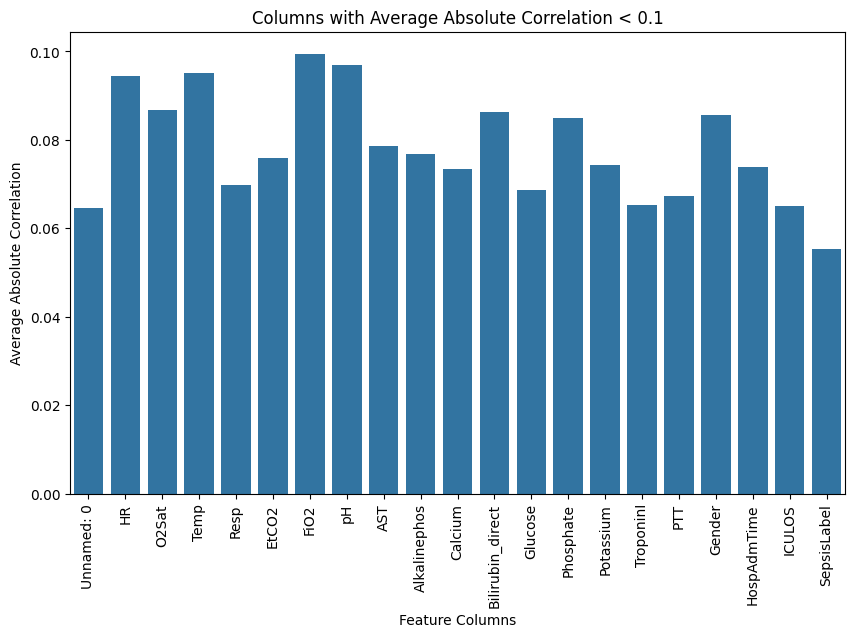

In [11]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

abs_corr_matrix = corr_matrix.abs()

n = len(feature_columns)
mean_abs_corr = (abs_corr_matrix.sum() - 1) / (n - 1)

low_corr_columns = mean_abs_corr[mean_abs_corr < 0.1]

plt.figure(figsize=(10, 6))
sns.barplot(x=low_corr_columns.index, y=low_corr_columns.values)
plt.xticks(rotation=90)
plt.title('Columns with Average Absolute Correlation < 0.1')
plt.ylabel('Average Absolute Correlation')
plt.xlabel('Feature Columns')
plt.show()

Now we chose the 20 columns with the lowest correlation for the next sections and we plot them for better visualization.

In [12]:
sorted_mean_abs_corr = mean_abs_corr.sort_values()

top_20_low_corr_columns = sorted_mean_abs_corr.head(21)

print("Top 20 columns with the lowest average absolute correlations:")
print(top_20_low_corr_columns.index.tolist())

Top 20 columns with the lowest average absolute correlations:
['SepsisLabel', 'Unnamed: 0', 'ICULOS', 'TroponinI', 'PTT', 'Glucose', 'Resp', 'Calcium', 'HospAdmTime', 'Potassium', 'EtCO2', 'Alkalinephos', 'AST', 'Phosphate', 'Gender', 'Bilirubin_direct', 'O2Sat', 'HR', 'Temp', 'pH', 'FiO2']


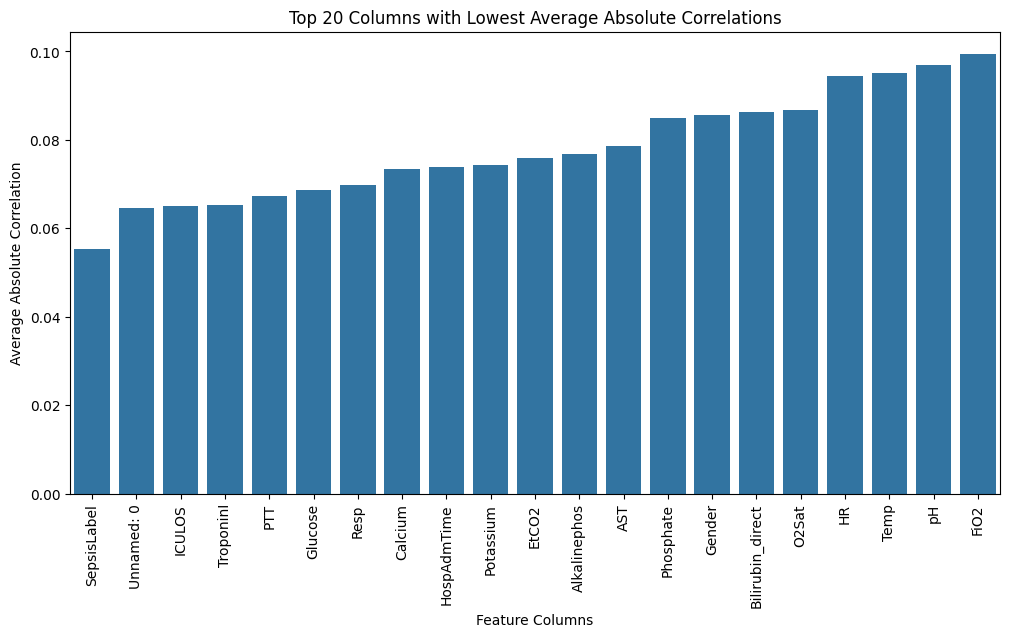

In [13]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_20_low_corr_columns.index, y=top_20_low_corr_columns.values)
plt.xticks(rotation=90)
plt.title('Top 20 Columns with Lowest Average Absolute Correlations')
plt.ylabel('Average Absolute Correlation')
plt.xlabel('Feature Columns')
plt.show()

#### 2.3.1.3. Why should we chose the columns with the lowest correlation?

* __Reducing Redundancy__: Columns with low correlations to others provide unique information not already captured by other features, minimizing overlap in the dataset.

* __Feature Selection__: In machine learning, especially for models sensitive to multicollinearity, low-correlation features reduce the risk of overfitting and improve model stability.

* __Dimensionality Reduction__: By choosing less correlated columns, we can reduce the number of features while retaining diverse information, making models more efficient.

* __Better Prediction__: Selecting features that capture different aspects of the data can enhance predictive performance by avoiding redundant information.

#### 2.3.1.4. Grouping the data by Patient ID

In this section we will group Patients based on their ID

In [14]:
grouped_validation_data = validation_data.groupby('Patient_ID')
grouped_test_data = test_data.groupby('Patient_ID')
grouped_train_data = train_data.groupby('Patient_ID')

print(f"Number of patients in train data: {len(grouped_train_data)}")
print(f"Number of patients in test data: {len(grouped_test_data)}")
print(f"Number of patients in validation data: {len(grouped_validation_data)}")

Number of patients in train data: 656
Number of patients in test data: 29
Number of patients in validation data: 82


### 2.3.2. Visualizing a Patient and Differentiating

We first visualize the HR column for the patient with id 1 during train, validation and test datasets

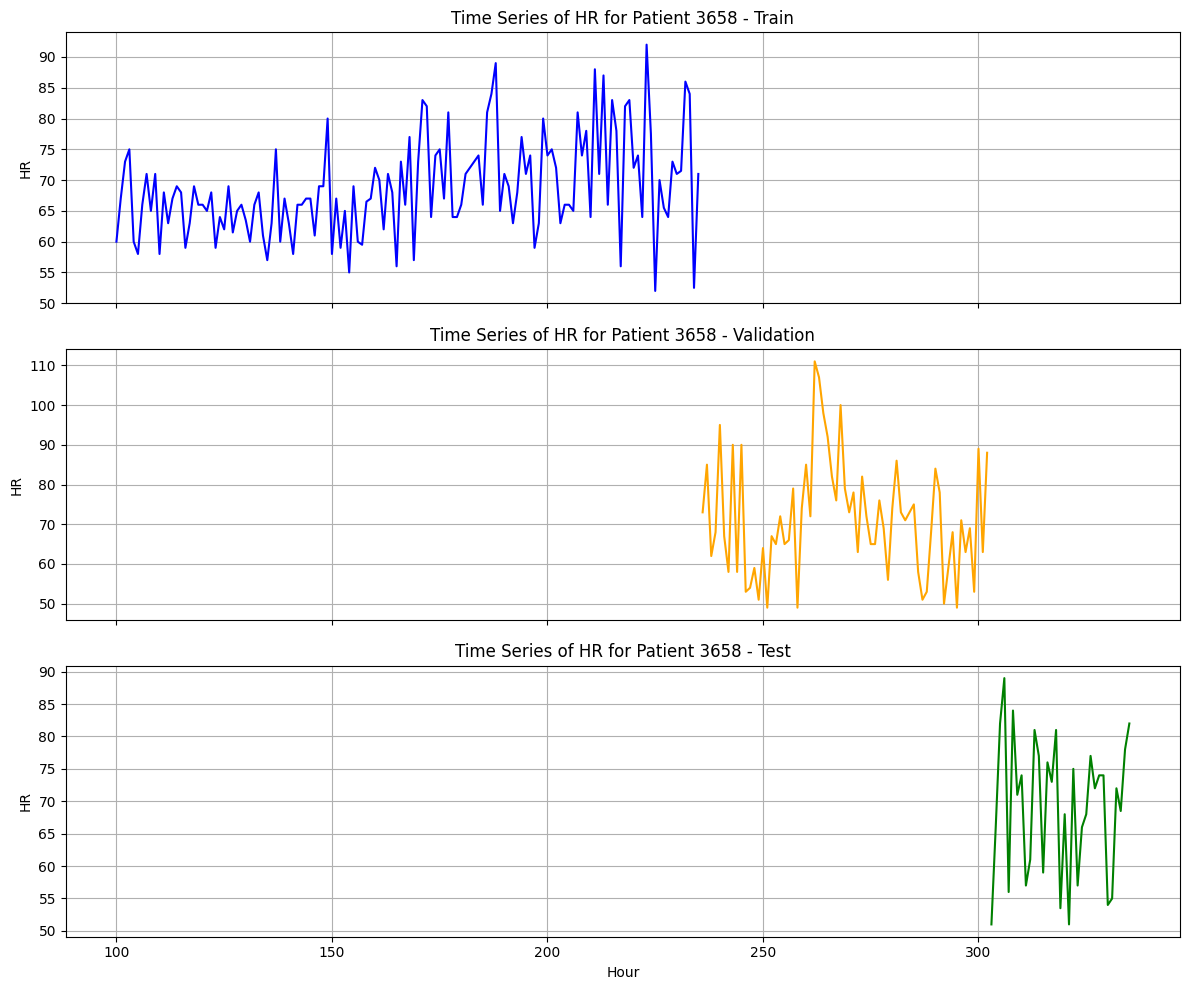

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

Patient_ID = 3658

train_hr = grouped_train_data.get_group(Patient_ID)[['Hour', 'HR']].set_index('Hour')
validation_hr = grouped_validation_data.get_group(Patient_ID)[['Hour', 'HR']].set_index('Hour')
test_hr = grouped_test_data.get_group(Patient_ID)[['Hour', 'HR']].set_index('Hour')

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(train_hr.index, train_hr['HR'], label='Train', color='blue')
axes[0].set_title(f'Time Series of HR for Patient {Patient_ID} - Train')
axes[0].set_ylabel('HR')
axes[0].grid(True)

axes[1].plot(validation_hr.index, validation_hr['HR'], label='Validation', color='orange')
axes[1].set_title(f'Time Series of HR for Patient {Patient_ID} - Validation')
axes[1].set_ylabel('HR')
axes[1].grid(True)

axes[2].plot(test_hr.index, test_hr['HR'], label='Test', color='green')
axes[2].set_title(f'Time Series of HR for Patient {Patient_ID} - Test')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('HR')
axes[2].grid(True)

plt.tight_layout()
plt.show()

Now we differentiate to calculate the value of d, but first let's discuss what differencing is and why it is useful for us:

Differencing is a technique used in time series to transform a non-stationary time series into a stationary one. A stationary time series has a constant mean and variance over time, which is an assumption for many statistical models. Non-stationary series often exhibit trends (like a consistent upward or downward movement) or seasonal patterns, which can make it difficult to model and forecast accurately. By differencing we can remove these trends and stabilize the mean, making the series easier to analyze by our model.

So below we will be preforming this and we will use the ADF test, which gives us a p-value for the assumption that the time series is non-stationary, we will continue differencing until the p-value is below a certain threshold so we can assume the time series is stationary.

In [16]:
from statsmodels.tsa.stattools import adfuller

full_hr = pd.concat([train_hr, validation_hr, test_hr]).sort_index()
# full_hr = train_hr
print(full_hr)

def adf_test(series):
    result = adfuller(series.dropna())
    return result[1] * 100

p_value = adf_test(full_hr['HR'])
print(f"Original series p-value: {p_value:.4f}")

d = 0

while p_value >= 0.05:
    d += 1
    full_hr['HR'] = full_hr['HR'].diff().dropna()
    p_value = adf_test(full_hr['HR'])
    print(f"After {d} differencing, p-value: {p_value:.4f}")

print(f"Stationarity achieved after {d} differencing. Final p-value: {p_value:.4f}")

        HR
Hour      
100   60.0
101   67.0
102   73.0
103   75.0
104   60.0
...    ...
331   55.0
332   72.0
333   68.5
334   78.0
335   82.0

[236 rows x 1 columns]
Original series p-value: 0.0018
Stationarity achieved after 0 differencing. Final p-value: 0.0018


As we can see the p-value was already below 5%, so there is no need for further differencing

### 2.3.3. Plotting Autocorrelation and Training a SARIMAX model

##### 2.3.3.1. Plotting the Autocorrelation and Partial Autocorrelation

In this section we are going to plot the autocorrelation and partial autocorrelation so we determine the MA and AR values, below is a brief explanation of these graphs I found on the internet:

__Autocorrelation (ACF) Graph__:

The autocorrelation function (ACF) measures how a time series correlates with its own past values at different lags. In simpler terms, it shows whether the value of a series at one point in time is related to its values at previous points. The ACF plot displays these correlation coefficients for various lags (e.g., lag 1, lag 2). In time series analysis, the ACF is particularly useful for identifying the Moving Average (MA) component of a model. If the ACF plot shows a sharp drop to near zero after a specific lag, that lag indicates the MA order.

__Partial Autocorrelation (PACF) Graph__:

The partial autocorrelation function (PACF) measures the direct correlation between a time series and its lagged values, after removing the effects of earlier lags. Unlike the ACF, which includes indirect effects, the PACF isolates the unique contribution of each lag. The PACF plot shows these partial correlation coefficients across lags. It’s key for identifying the Autoregressive (AR) component of a model. A sharp drop in the PACF after a certain lag suggests the AR order.

        HR  O2Sat
Hour             
100   60.0   99.0
101   67.0   99.0
102   73.0   99.0
103   75.0  100.0
104   60.0   99.0
...    ...    ...
331   55.0   93.0
332   72.0  100.0
333   68.5  100.0
334   78.0  100.0
335   82.0  100.0

[236 rows x 2 columns]


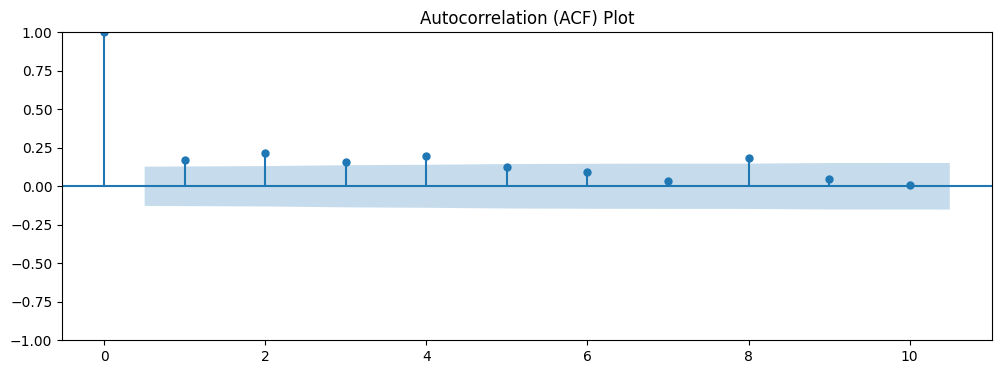

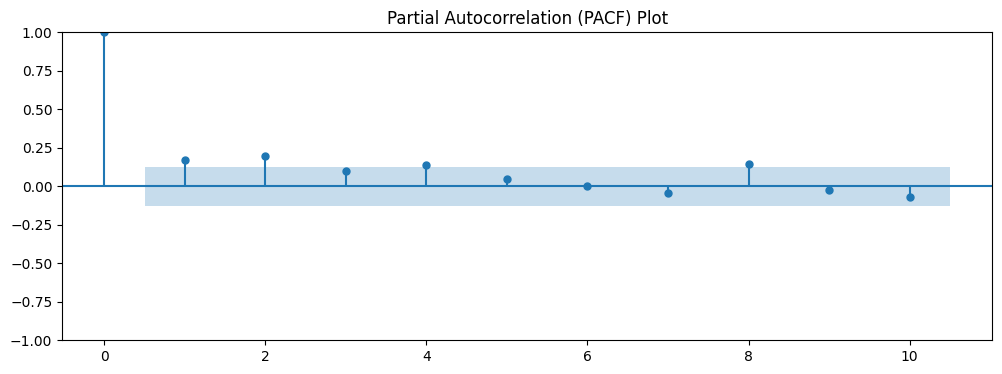

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Patient_ID = 3658
train_sarimax = grouped_train_data.get_group(Patient_ID)[['Hour', 'HR', 'O2Sat']].set_index('Hour')
validation_sarimax = grouped_validation_data.get_group(Patient_ID)[['Hour', 'HR', 'O2Sat']].set_index('Hour')
test_sarimax = grouped_test_data.get_group(Patient_ID)[['Hour', 'HR', 'O2Sat']].set_index('Hour')

full_data = pd.concat([train_sarimax, validation_sarimax, test_sarimax]).sort_values('Hour')
print(full_data)

full_hr = full_data[['HR']]
full_sat2o = full_data[['O2Sat']]

plt.figure(figsize=(12, 4))
plot_acf(full_hr['HR'], lags=10, ax=plt.gca())
plt.title('Autocorrelation (ACF) Plot')
plt.savefig('acf_plot.png')

plt.figure(figsize=(12, 4))
plot_pacf(full_hr['HR'], lags=10, ax=plt.gca())
plt.title('Partial Autocorrelation (PACF) Plot')
plt.savefig('pacf_plot.png')

From the plots above, we can see two drops, one at the very beginning in both graphs and one near the values 6 and 7, so next we test the SARIMAX (Seasonal AutoRegressive Integrated Moving Average with eXogenous regressors) model with both of these values.

##### 2.3.3.2. SARIMAX

No we will use a simple SARIMAX model to predict the HR

/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/

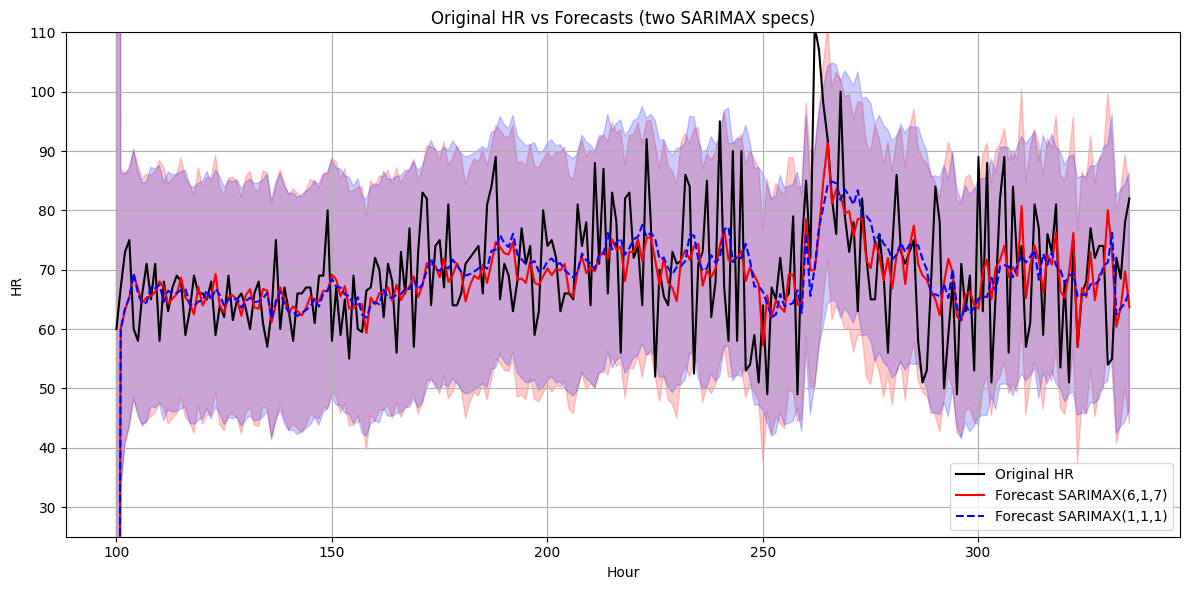

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

specs = {
    "SARIMAX(6,1,7)": (6, 1, 7),
    "SARIMAX(1,1,1)": (1, 1, 1),
}

forecasts = {}
cis = {}

for name, (p, d, q) in specs.items():
    model = SARIMAX(
        endog=full_hr['HR'],
        exog=full_sat2o['O2Sat'],
        order=(p, d, q)
    )
    results = model.fit(disp=False)
    
    pred = results.get_prediction(
        start=0,
        end=len(full_hr)-1,
        exog=full_sat2o['O2Sat']
    )
    forecasts[name] = pred.predicted_mean
    cis[name] = pred.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(full_hr.index, full_hr['HR'], label='Original HR', color='black')

styles = {
    "SARIMAX(6,1,7)": dict(color='red',   linestyle='-'),
    "SARIMAX(1,1,1)": dict(color='blue',  linestyle='--'),
}

for name in specs:
    plt.plot(
        full_hr.index, forecasts[name],
        label=f'Forecast {name}',
        **styles[name]
    )
    lower = cis[name].iloc[:, 0]
    upper = cis[name].iloc[:, 1]
    plt.fill_between(
        full_hr.index,
        lower, upper,
        alpha=0.2,
        **{k: styles[name][k] for k in ('color',)}
    )

plt.title('Original HR vs Forecasts (two SARIMAX specs)')
plt.xlabel('Hour')
plt.ylabel('HR')
plt.ylim(25, 110)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

As we can see, the red model has had a slightly better prediction (judging the performance visually)

### 2.3.4. R2 Score & Data Normalization

#### 2.3.4.1. R2 Score and plot

In this section, we will be calculating the R2 score for the SARIMAX models and then plot its results on the test data (for this we will change the code of the last section and modify it so it calculates the r2 and draws the plot only for the test portion).

But before that let's briefly explain the R2-score:

R2-score is a scoring method used for evaluating regression methods, it's calculated using the formula below:

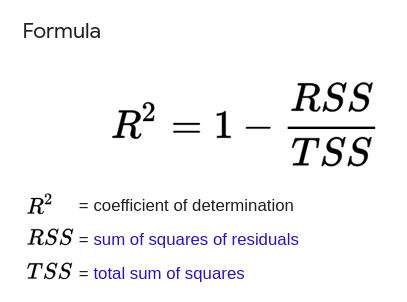

"The coefficient of determination (R²) is a number between 0 and 1 that measures how well a statistical model predicts an outcome. You can interpret the R² as the proportion of variation in the dependent variable that is predicted by the statistical model." (https://www.scribbr.com/statistics/coefficient-of-determination/)

The higher this number is, the better the performance of the model is.

/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/home/smani24/Desktop/Repositories/Neural-Network-and-Deep-Learning/NNenv/lib/python3.10/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/

R² for SARIMAX(6,1,7) on test set: 0.0433
R² for SARIMAX(1,1,1) on test set: -0.1516
R² for SARIMAX(7,1,8) on test set: 0.2726


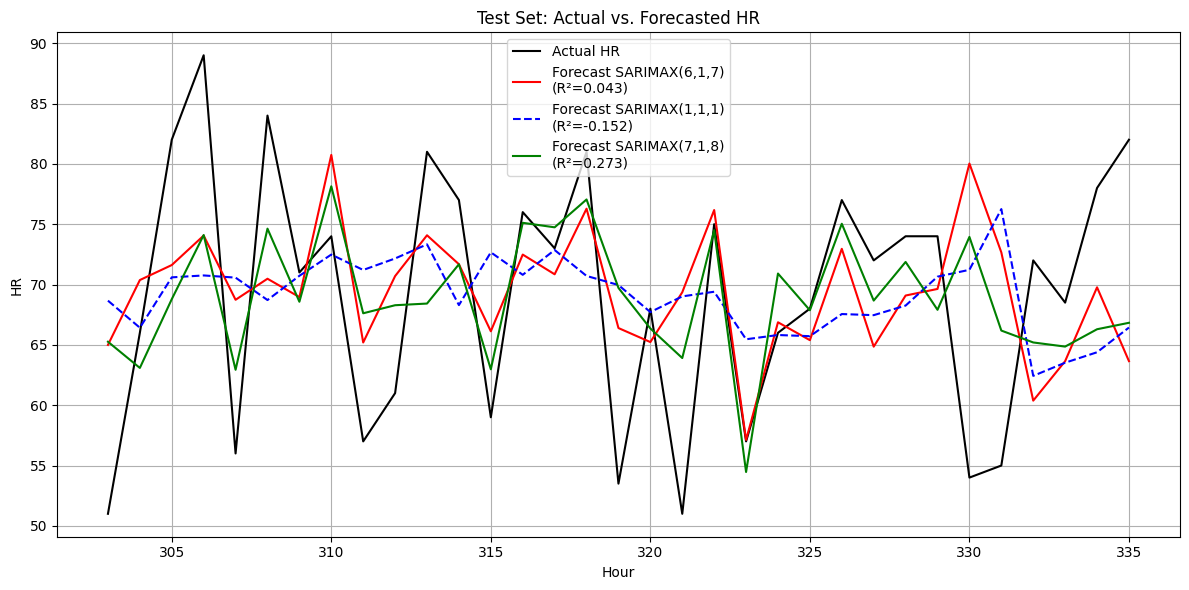

In [19]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import r2_score

x = 7
y = 8
specs = {
    "SARIMAX(6,1,7)": (6, 1, 7),
    "SARIMAX(1,1,1)": (1, 1, 1),
    f"SARIMAX({x},1,{y})": (x, 1, y),
}

results = {}
test_forecasts = {}
r2_scores = {}

for name, (p, d, q) in specs.items():
    model = SARIMAX(
        endog=full_hr['HR'],
        exog=full_sat2o['O2Sat'],
        order=(p, d, q)
    )
    res = model.fit(disp=False)
    results[name] = res

    start = len(full_hr) - len(test_hr)
    end   = len(full_hr) - 1
    pred = res.get_prediction(
        start=start,
        end=end,
        exog=test_sarimax['O2Sat']
    )
    fc_mean = pred.predicted_mean
    test_forecasts[name] = fc_mean.reset_index(drop=True)
    
    r2 = r2_score(test_hr['HR'].reset_index(drop=True), fc_mean.reset_index(drop=True))
    r2_scores[name] = r2

for name, r2 in r2_scores.items():
    print(f"R² for {name} on test set: {r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(test_hr.index, test_hr['HR'], label='Actual HR', color='black')

styles = {
    "SARIMAX(6,1,7)": dict(color='red',   linestyle='-'),
    "SARIMAX(1,1,1)": dict(color='blue',  linestyle='--'),
    f"SARIMAX({x},1,{y})": dict(color='green',  linestyle='-'),
}

for name in specs:
    fc = test_forecasts[name]
    fc.index = test_hr.index
    plt.plot(
        fc.index, fc, 
        label=f'Forecast {name}\n(R²={r2_scores[name]:.3f})',
        **styles[name]
    )

plt.title('Test Set: Actual vs. Forecasted HR')
plt.xlabel('Hour')
plt.ylabel('HR')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('hr_test_comparison.png')
plt.show()


As we can see, the blue model (1, 1, 1) had a negative R2 which means it's worse than a horizontal mean line! But the model trained in the last section (6, 1, 7) had a better performance (still pretty bad however).

After drawing these plots and calculating the R2 score and looking back at the autocorrelation plots again, we can see that the values could have been chosen differently (7, 1, 8) and as we can see by the green plot, after making this adjustment we were able to get a much better model with a r2 of 0.273 (which still isn't ideal but better than before)

#### 2.3.4.2. Normalizing

In this section we will normalize the data, we will use a MinMax normalizer and normalize the hour column separately.

In [20]:
from sklearn.preprocessing import MinMaxScaler

feature_columns = [col for col in train_data.columns if col not in ['Patient_ID', 'Hour']]
scaler = MinMaxScaler()
scaler.fit(train_data[feature_columns])

train_data[feature_columns] = scaler.transform(train_data[feature_columns])
validation_data[feature_columns] = scaler.transform(validation_data[feature_columns])
test_data[feature_columns] = scaler.transform(test_data[feature_columns])

hour_scaler = MinMaxScaler()
hour_scaler.fit(train_data[['Hour']])
train_data['Hour'] = hour_scaler.transform(train_data[['Hour']])
validation_data['Hour'] = hour_scaler.transform(validation_data[['Hour']])
test_data['Hour'] = hour_scaler.transform(test_data[['Hour']])

#### 2.3.4.3. Why Weren’t Mean-and-Variance-Based Normalizers Used? 

Mean-and-variance-based normalizers (such as StandardScaler) adjust data to have a mean of 0 and variance of 1. However, due to the following reasons, Min-Max scaling was chosen:

* Bounded Data: Vital signs like 'HR' have natural ranges and are not negative. Min-Max scaling keeps data within [0, 1], preserving these bounds for interpretability, while mean-and-variance scaling could introduce negative values, which are less meaningful.

* Neural Network Compatibility: since neural networks are used later, they often perform better with inputs in [0, 1] due to activation functions like sigmoid or tanh, which are scale-sensitive.

Mean-and-variance scaling could distort the data’s natural constraints and model assumptions, making Min-Max scaling more suitable for this task.

## 2.4. Training Deep Learning Models

### 2.4.1. Window Length & Explained Variance Score

#### 2.4.1.1. Determining Window Lengths

When training deep learning models for time series prediction, the data must be windowed in two ways: the input window and the output window. These windows define how much data the model uses to make predictions and how far into the future it predicts.

__Input Window__

The input window represents the length of historical time series data that the model sees to predict future values. To determine an appropriate length, we can leverage insights from statistical analyses portion:

* Autocorrelation Function (ACF) Plot: The ACF measures how correlated a time series is with its past values at various lags. The lag at which the ACF drops to insignificant levels indicates how much past data is relevant.

* Partial Autocorrelation Function (PACF) Plot: The PACF isolates the direct correlation between the current value and past lags, excluding indirect effects. Similarly it can be used to determine the window size.

* SARIMAX Model Parameters: In a SARIMAX model, the autoregressive (AR) order, denoted by p, indicates how many past time steps are used in the model.

To choose the input window length, we typically take the maximum of these indicators to ensure the model captures the most relevant historical dependencies. which is 8 in our case.

__Output Window__

The output window defines how many time steps into the future the model predicts. This length depends on the forecasting task and since it's not been specified we also set it to 1 for now since a high value results in a lower model performance.

#### 2.4.1.2. Explained Variance Score

The Explained Variance Score is a performance metric that evaluates how well a model’s predictions capture the variability in the target variable. It is defined as:

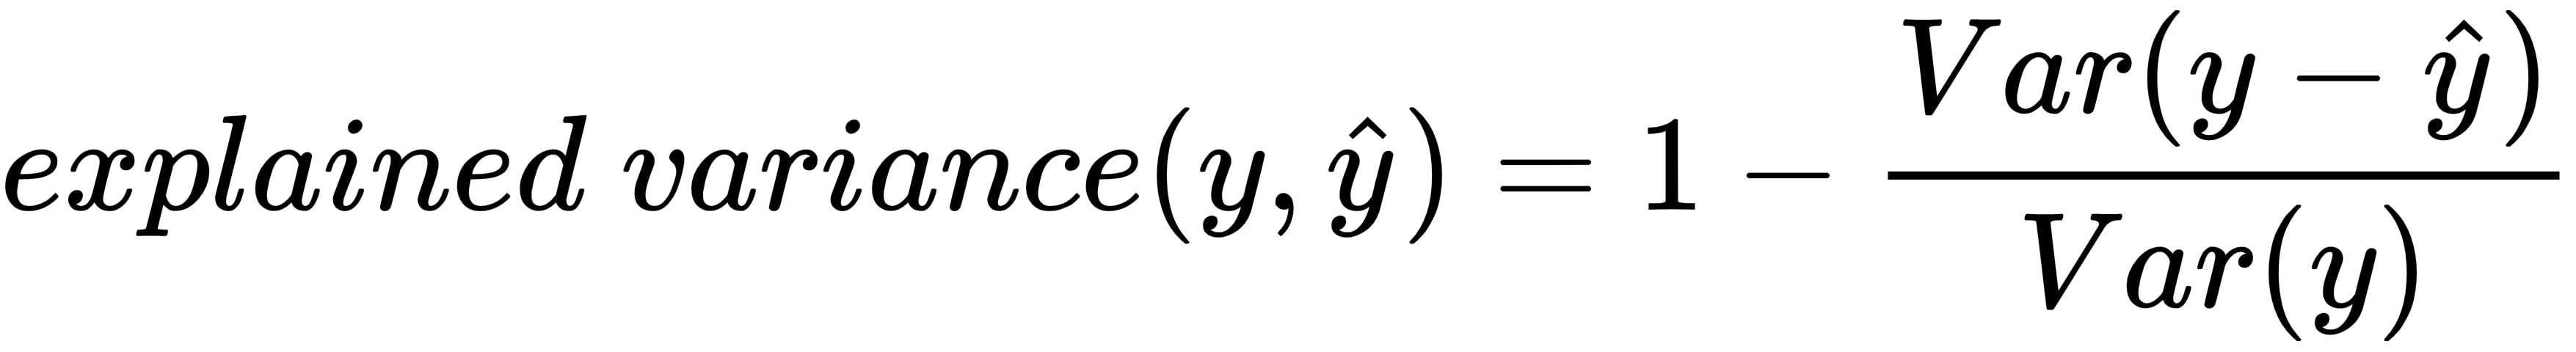

where:

y  is the true time series value,
y_hat is the predicted value,
var denotes variance.

The score ranges from minus infinity to 1:

A score of 1 means the model perfectly explains all variance in the data.
A score of 0 indicates the model performs no better than predicting the mean.
A negative score suggests the model performs worse than the mean.


#### 2.4.1.3. Why is Explained Variance Score Important?

Based on this article (https://koshurai.medium.com/understanding-explained-variance-score-a-key-metric-for-regression-analysis-17b31f50108c) below are some of the resons why this metric is important.

__1. Model Evaluation__:

The Explained Variance Score is crucial for assessing how well a regression model fits the data. It helps data scientists understand if their model is effectively capturing the relationships in the data.

__2. Model Comparison__:

When experimenting with different regression algorithms, the Explained Variance Score provides a consistent metric to compare the performance of each model. A higher score indicates a better fit.

__3. Identifying Improvement Areas__:

A low Explained Variance Score might signal that the model is missing key features or that the model needs further tuning. This can guide data scientists in refining their models for better performance.

### 2.4.2. Training Dense, LSTM & GRU models

Before we begin the training, since we are not going to predict a sequence like it was done in the paper and instead we are going to predict the HR column, we need to change the previously designed models a bit, and switch to a ReLU activation function instead of a sigmoid for this regression task.

In [21]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Hyperparameters
input_window = 8
num_features = 20
output_window = 1
H = 512
learning_rate = 0.0001

# Dense Model
dense_model = models.Sequential([
    layers.Input(shape=(input_window * num_features,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(output_window, activation='linear')
])
dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)
dense_model.summary()

# LSTM Model
lstm_model = models.Sequential([
    layers.Input(shape=(input_window, num_features)),
    layers.LSTM(H, return_sequences=False),
    layers.Dense(output_window, activation='linear')
])
lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)
lstm_model.summary()

# GRU Model
gru_model = models.Sequential([
    layers.Input(shape=(input_window, num_features)),
    layers.GRU(H, return_sequences=False),
    layers.Dense(output_window, activation='linear')
])
gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)
gru_model.summary()


bi_lstm_model = models.Sequential([
    layers.Input(shape=(input_window, num_features)),
    layers.Bidirectional(layers.LSTM(H, return_sequences=False)),
    layers.Dense(output_window, activation='linear')
])
bi_lstm_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)
bi_lstm_model.summary()

# Bidirectional GRU Model
bi_gru_model = models.Sequential([
    layers.Input(shape=(input_window, num_features)),
    layers.Bidirectional(layers.GRU(H, return_sequences=False)),
    layers.Dense(output_window, activation='linear')
])
bi_gru_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
    loss='mean_squared_error'
)
bi_gru_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │        20,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,737 (81.00 KB)

 Trainable params: 20,737 (81.00 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_3 (Bidirectional) │ (None, 1024)           │     1,640,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 1)              │         1,025 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,641,473 (6.26 MB)

 Trainable params: 1,641,473 (6.26 MB)

 Non-trainable params: 0 (0.00 B)

Now we will train the models and plot the results.

In [22]:
top_20_low_corr_columns = list(top_20_low_corr_columns.keys())
feature_columns = [col for col in top_20_low_corr_columns if col != 'HR']
print(feature_columns)

['SepsisLabel', 'Unnamed: 0', 'ICULOS', 'TroponinI', 'PTT', 'Glucose', 'Resp', 'Calcium', 'HospAdmTime', 'Potassium', 'EtCO2', 'Alkalinephos', 'AST', 'Phosphate', 'Gender', 'Bilirubin_direct', 'O2Sat', 'Temp', 'pH', 'FiO2']


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

def create_sequences(data, input_window, output_window, feature_columns, target_column):
    X, y = [], []
    for i in range(len(data) - input_window - output_window + 1):
        X.append(data[feature_columns].iloc[i:i + input_window].values)
        y.append(data[target_column].iloc[i + input_window:i + input_window + output_window].values)
    return np.array(X), np.array(y)

train_sequences = []
for patient_id, group in train_data.groupby('Patient_ID'):
    patient_data = group[feature_columns + ['HR']]
    X, y = create_sequences(patient_data, input_window=input_window, output_window=output_window, 
                          feature_columns=feature_columns , target_column='HR')
    if X.size > 0:
        train_sequences.append((X, y))

val_sequences = []
for patient_id, group in validation_data.groupby('Patient_ID'):
    patient_data = group[feature_columns  + ['HR']]
    X, y = create_sequences(patient_data, input_window=input_window, output_window=output_window, 
                          feature_columns=feature_columns , target_column='HR')
    if X.size > 0:
        val_sequences.append((X, y))

# Combine sequences from all patients
X_train = np.vstack([seq[0] for seq in train_sequences])
y_train = np.vstack([seq[1] for seq in train_sequences])
X_val = np.vstack([seq[0] for seq in val_sequences])
y_val = np.vstack([seq[1] for seq in val_sequences])

X_train_dense = X_train.reshape(X_train.shape[0], -1)
X_val_dense = X_val.reshape(X_val.shape[0], -1)

# Train Dense model
dense_history = dense_model.fit(
    X_train_dense, y_train,
    validation_data=(X_val_dense, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

# Train LSTM model
lstm_history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

# Train GRU model
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50


I0000 00:00:1748717006.518067  113636 service.cc:152] XLA service 0x7bf54c0e3830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748717006.518079  113636 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4060 Laptop GPU, Compute Capability 8.9
2025-05-31 22:13:26.526403: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1748717006.566959  113636 cuda_dnn.cc:529] Loaded cuDNN version 90701
I0000 00:00:1748717006.696997  113636 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1068/1068 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0262 - val_loss: 0.0082
Epoch 2/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss: 0.0085 - val_loss: 0.0078
Epoch 3/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 679us/step - loss: 0.0083 - val_loss: 0.0085
Epoch 4/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 663us/step - loss: 0.0080 - val_loss: 0.0093
Epoch 5/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 684us/step - loss: 0.0079 - val_loss: 0.0071
Epoch 6/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 681us/step - loss: 0.0078 - val_loss: 0.0080
Epoch 7/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 674us/step - loss: 0.0075 - val_loss: 0.0074
Epoch 8/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 697us/step - loss: 0.0074 - val_loss: 0.0067
Epoch 9/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 643us/step - loss: 0.0073 - val_loss: 0.0095
Epoch 10/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 673us/step - loss: 0.0072 - val_loss: 0.0087
Epoch 11/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 1s 664us/step - loss: 0.0071 - val_loss: 0.0072
Epoch 12/50
1068/1068

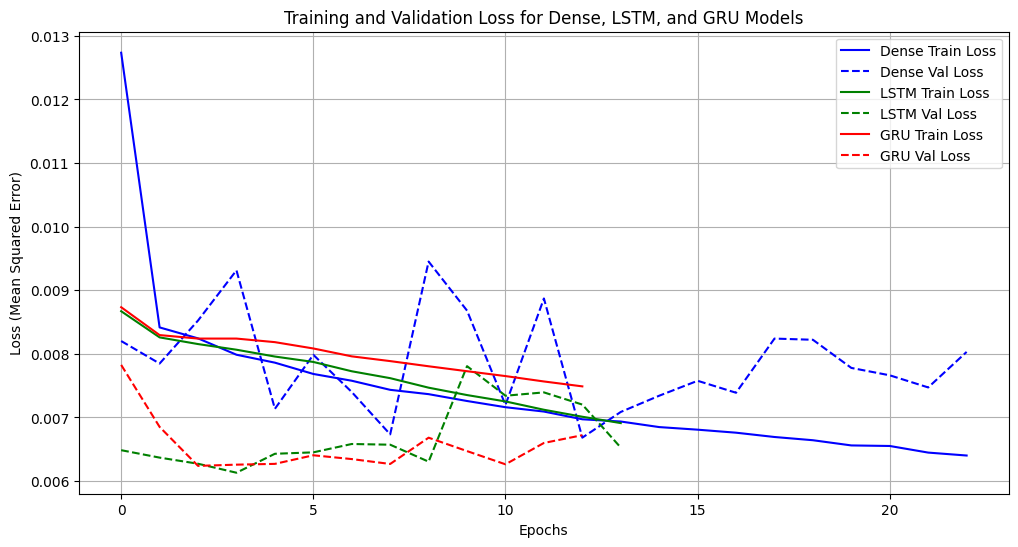

In [24]:
plt.figure(figsize=(12, 6))

plt.plot(dense_history.history['loss'], label='Dense Train Loss', color='blue')
plt.plot(dense_history.history['val_loss'], label='Dense Val Loss', color='blue', linestyle='--')
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss', color='green')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss', color='green', linestyle='--')
plt.plot(gru_history.history['loss'], label='GRU Train Loss', color='red')
plt.plot(gru_history.history['val_loss'], label='GRU Val Loss', color='red', linestyle='--')

plt.title('Training and Validation Loss for Dense, LSTM, and GRU Models')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### 2.4.3. Training Bi-Directional LSTM & GRU models

Now we will train the Bi-Direction LSTM and GRU models with a similar code

In [25]:
bi_lstm_history = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

# Train Bidirectional GRU model
bi_gru_history = bi_gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1,
    callbacks=[early_stopping]
)

Epoch 1/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0104 - val_loss: 0.0087
Epoch 2/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0084 - val_loss: 0.0066
Epoch 3/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0082 - val_loss: 0.0071
Epoch 4/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0081 - val_loss: 0.0080
Epoch 5/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0080 - val_loss: 0.0066
Epoch 6/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0079 - val_loss: 0.0069
Epoch 7/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0076 - val_loss: 0.0084
Epoch 8/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0076 - val_loss: 0.0079
Epoch 9/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0074 - val_loss: 0.0082
Epoch 10/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0074 - val_loss: 0.0078
Epoch 11/50
1068/1068 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0073 - val_loss: 0.0074
Epoch 12/50
1068/1068 ━━━━━━━━

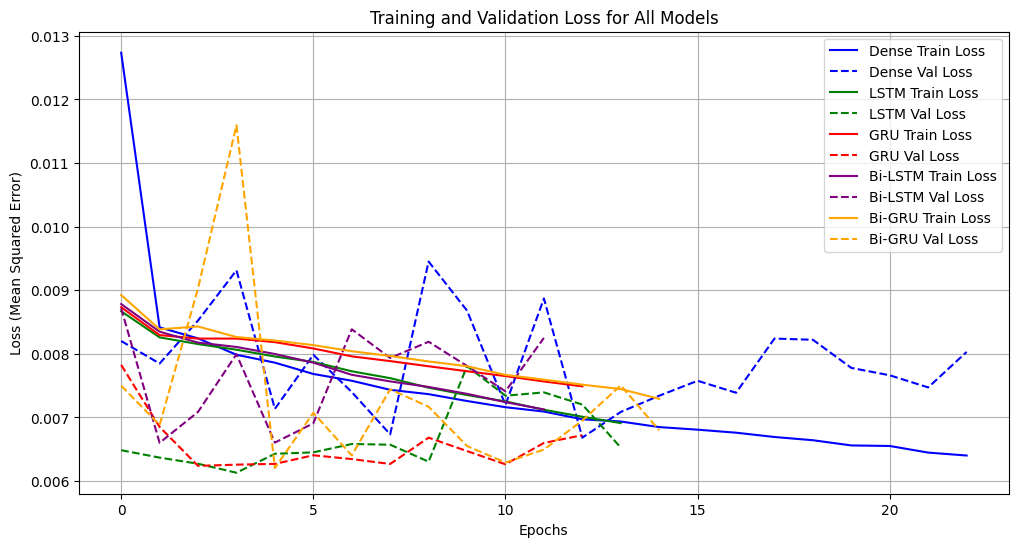

In [26]:
plt.figure(figsize=(12, 6))

# Dense model
plt.plot(dense_history.history['loss'], label='Dense Train Loss', color='blue')
plt.plot(dense_history.history['val_loss'], label='Dense Val Loss', color='blue', linestyle='--')

# LSTM model
plt.plot(lstm_history.history['loss'], label='LSTM Train Loss', color='green')
plt.plot(lstm_history.history['val_loss'], label='LSTM Val Loss', color='green', linestyle='--')

# GRU model
plt.plot(gru_history.history['loss'], label='GRU Train Loss', color='red')
plt.plot(gru_history.history['val_loss'], label='GRU Val Loss', color='red', linestyle='--')

# Bidirectional LSTM model
plt.plot(bi_lstm_history.history['loss'], label='Bi-LSTM Train Loss', color='purple')
plt.plot(bi_lstm_history.history['val_loss'], label='Bi-LSTM Val Loss', color='purple', linestyle='--')

# Bidirectional GRU model
plt.plot(bi_gru_history.history['loss'], label='Bi-GRU Train Loss', color='orange')
plt.plot(bi_gru_history.history['val_loss'], label='Bi-GRU Val Loss', color='orange', linestyle='--')

plt.title('Training and Validation Loss for All Models')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

### 2.4.4. Calculating the metrics

Now we will report the values of Loss, MSE, MAE, R2 score, and Cosine Distance. for all the models in a single table using the following code. 

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.spatial.distance import cosine

test_sequences = []
for patient_id, group in test_data.groupby('Patient_ID'):
    patient_data = group[feature_columns + ['HR']]
    X, y = create_sequences(patient_data, input_window=input_window, output_window=output_window, 
                            feature_columns=feature_columns, target_column='HR')
    if X.size > 0:
        test_sequences.append((X, y))

X_test = np.vstack([seq[0] for seq in test_sequences])
y_test = np.vstack([seq[1] for seq in test_sequences])

def compute_metrics(model, X, y_true, is_dense=False):
    if is_dense:
        X = X.reshape(X.shape[0], -1)
    y_pred = model.predict(X)
    loss = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    cosine_dist = np.mean([cosine(y_true[i], y_pred[i]) for i in range(len(y_true))])
    return loss, loss, mae, r2, cosine_dist

metrics = {
    'Dense': compute_metrics(dense_model, X_test, y_test, is_dense=True),
    'LSTM': compute_metrics(lstm_model, X_test, y_test),
    'GRU': compute_metrics(gru_model, X_test, y_test),
    'Bi-LSTM': compute_metrics(bi_lstm_model, X_test, y_test),
    'Bi-GRU': compute_metrics(bi_gru_model, X_test, y_test)
}

metrics_df = pd.DataFrame(metrics, index=['Loss', 'MSE', 'MAE', 'R² Score', 'Cosine Distance']).T
print("Model Evaluation Metrics:")
print(metrics_df)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Model Evaluation Metrics:
             Loss       MSE       MAE  R² Score  Cosine Distance
Dense    0.010604  0.010604  0.087504 -0.683933     5.390654e-09
LSTM     0.005448  0.005448  0.055984  0.337360     5.032030e-09
GRU      0.005429  0.005429  0.057200  0.344905     5.181504e-09
Bi-LSTM  0.006031  0.006031  0.063891  0.105675     5.245596e-09
Bi-GRU   0.005328  0.005328  0.055918  0.384662     4.486388e-09


If the R2 score of a model is higher than 1, it means it has performed better than simply using the mean as the prediction. As we can see all the models except the Dense one have a R2 score higher than 0 so they all outperform the mean. and the best performing model was the Bi-GRU model.

## 2.6. Maximum Log-Likelihood Estimation

### 2.6.1. Designing a Network

#### 2.6.1.1. LSTM

We can use a LSTM as explained in the question to predict the variance and mean values.

In [ ]:
from tensorflow.keras import layers, models

input_window = 8    
output_window = 4   
num_features = 20   
lstm_units = 128    


input_seq = layers.Input(shape=(input_window, 2 * num_features))

lstm_out = layers.LSTM(lstm_units, return_sequences=False)(input_seq)

dense_out = layers.Dense(output_window * 2 * num_features)(lstm_out)

prediction = layers.Reshape((output_window, 2 * num_features))(dense_out)

model = models.Model(inputs=input_seq, outputs=prediction)

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 8, 40)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 128)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 160)            │        20,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 4, 40)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,168 (418.62 KB)

 Trainable params: 107,168 (418.62 KB)

 Non-trainable params: 0 (0.00 B)

#### 2.6.1.2. Why we assume variance and mean for each columns are independent?

We do this for the following reasons:

* __Independence Assumption__: Treating the mean and variance of each feature separately assumes that features are independent. This simplifies the model by avoiding the need to explicitly model cross-feature correlations.

* __Computational Efficiency__: Modeling each feature independently reduces the complexity of the network, making it more scalable as the number of features increases.

* __Interpretability__: Independent predictions per feature are easier to analyze and align with the system’s requirement for feature-specific statistics.

This approach may miss correlations between features (e.g., heart rate and blood pressure might covary). If such dependencies are significant, a more complex model might be needed, but the second-order approximation justifies this simplification.

#### 2.6.1.3. Can Previous Architectures Be Reused?

Yes, with Modifications:

Previous architectures (for predicting a single value like 'HR') can serve as a starting point. But adjustments are required to handle multiple features and dual outputs (mean and variance). The core LSTM structure remains applicable, but the input/output layers need resizing.

#### 2.6.1.4. Do we need to change the loss function?

MSE can still be used to measure the difference between predicted and true mean and variance values.
Since the goal is to minimize the difference between the guessed P and true P, MSE on mean and variance indirectly achieves this by aligning the sufficient statistics of the distribution.

#### 2.6.1.5. Do we need to change the activation function?

Mean and variance are both a real number so linear activation is appropriate, however if we want to ephesise the fact that variance needs to be positive, we can use another activation function like softplus for the head that predicts the variance.

Alternatively we could clip the values to resolve this issue.

### 2.6.2. Training the model

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras import layers, models
from sklearn.metrics import r2_score

input_window = 10  
output_window = 5  
num_features = 3   
lstm_units = 64    


input_seq = layers.Input(shape=(input_window, 2 * num_features))
lstm_out = layers.LSTM(lstm_units, return_sequences=False)(input_seq)
dense_out = layers.Dense(output_window * 2 * num_features)(lstm_out)
prediction = layers.Reshape((output_window, 2 * num_features))(dense_out)

model = models.Model(inputs=input_seq, outputs=prediction)
model.compile(optimizer='adam', loss='mean_squared_error')


history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32,
    verbose=1
)


plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')


y_pred = model.predict(X_test)
y_test_flat = y_test.reshape(-1, output_window * 2 * num_features)
y_pred_flat = y_pred.reshape(-1, output_window * 2 * num_features)
r2 = r2_score(y_test_flat, y_pred_flat)
print(f"R² Score on Test Data: {r2:.4f}")

Epoch 1/50


ValueError: Input 0 of layer "functional_9" is incompatible with the layer: expected shape=(None, 8, 40), found shape=(None, 8, 20)